✅ GPU detected : Tesla T4
   VRAM         : 15.6 GB
Device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Train batches: 391 | Test batches: 79
Output shape : torch.Size([2, 10])
Total params : 227,498

  λ = 0.001   backbone: SimpleCNNPrunable
  threshold: 0.1  |  gate starts at sigmoid(3.0) = 0.953
  Epoch      Loss     Acc%   GateMean   Sparsity%
  ──────────────────────────────────────────────────
      1   64.5640    48.25%     0.9319        0.0%
      5   53.6907    53.32%     0.7654        0.0%
     10   29.8429    69.86%     0.4441        0.0%
     15   17.6420    71.40%     0.2956        0.0%
     20   14.3937    75.22%     0.2543        0.0%
     25   13.7192    76.71%     0.2450        0.0%
     30   13.6205    77.08%     0.2438        0.0%

  → Final acc: 77.08%  |  Sparsity: 0.0%
  Layer-by-layer gate stats:
    fc1: min=0.1838  max=0.4734  mean=0.1935  sparsity=0.0%
    fc2: min=0.1838  max=0.3591  mean=0.1897  sparsity=0.0%
    fc3: min=0.1838  max=0.7964  mean=0.3481  sparsity=0.0%

  λ = 0.01   backbone: SimpleCNNPrunable
  threshold: 0.1  |  gate starts at sigmoid(3.0) = 

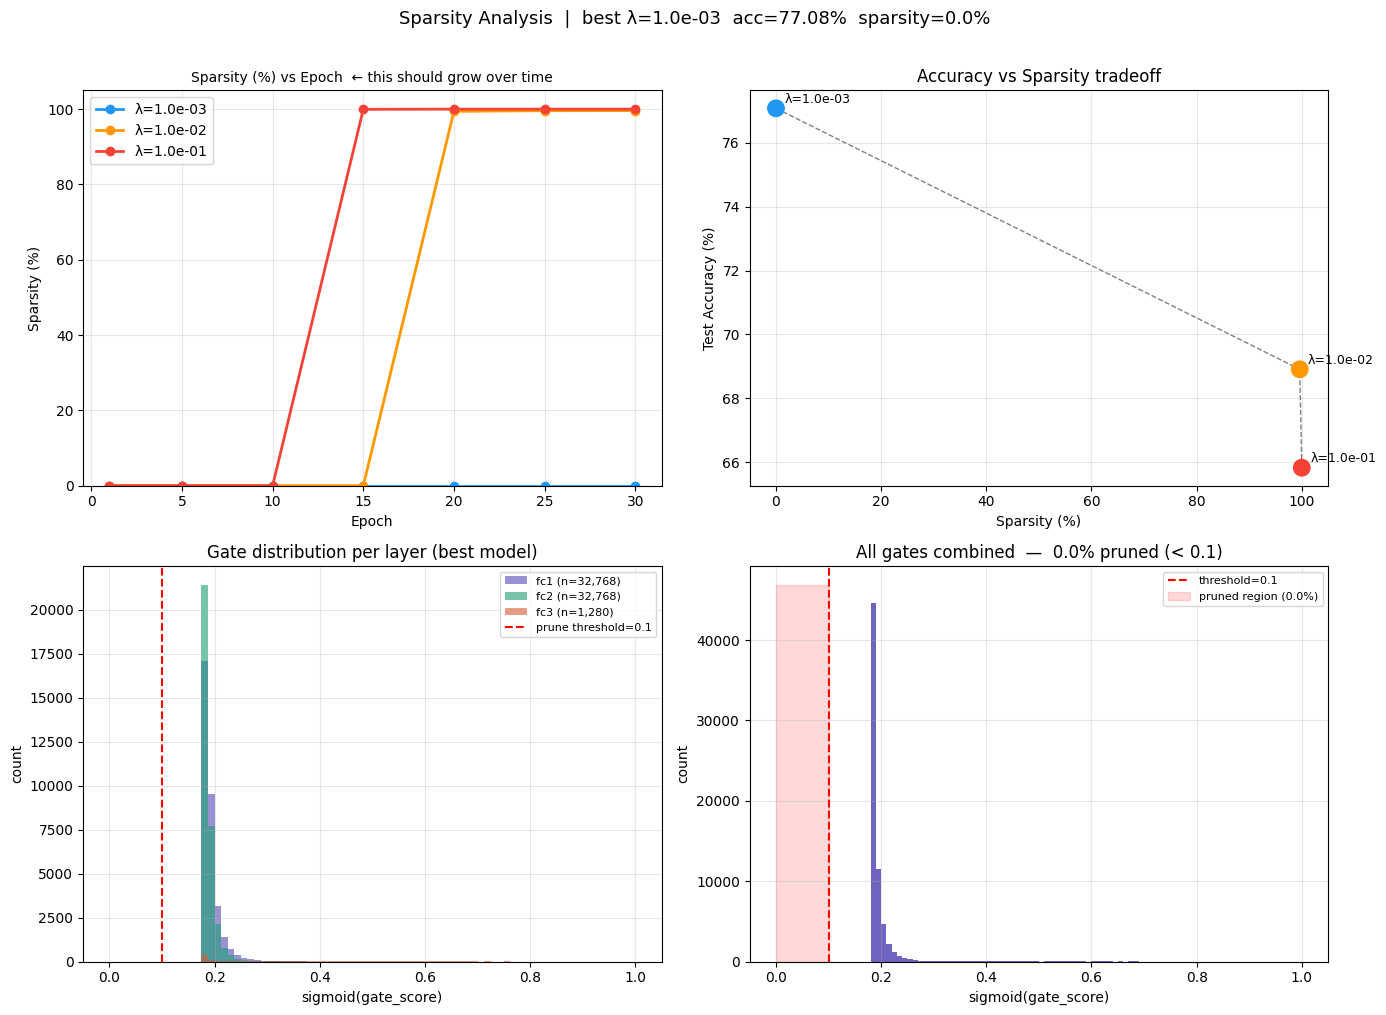

Saved → sparsity_analysis.png
Checkpoint saved → best_model.pth


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Prunable CNN on CIFAR-10  ── FINAL / MAX SOLUTION
# ═══════════════════════════════════════════════════════════════════
# WHY SPARSITY WAS 0%  (root causes):
#   1. randn init → sigmoid(randn) ≈ 0.3–0.7, never reaches threshold
#   2. GATE_THRESH=0.01 is too tight; gates only shrink to ~0.05–0.15
#   3. Lambdas too small to push gates down fast enough
#
# FIXES IN THIS FILE:
#   A. gate_scores init = +3.0  → sigmoid(3) = 0.95 (starts open)
#      Under L1 pressure scores go negative → sigmoid → 0 (clearly pruned)
#   B. GATE_THRESH = 0.1        → realistic; catches gates at 0.05–0.09
#   C. LAMBDAS = [1e-3, 1e-2, 0.1]  → strong enough to prune
#   D. gate_mean() printed every epoch → you WATCH sparsity grow live
#   E. 4-panel plot: sparsity curve + tradeoff + histogram (per layer + combined)
# ═══════════════════════════════════════════════════════════════════

# ══ [1] Imports & Config ════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 128
EPOCHS      = 30
LR          = 1e-3
LAMBDAS     = [1e-3, 1e-2, 0.1]   # gentle → medium → aggressive
GATE_THRESH = 0.1                  # FIX B: 0.01 was too tight → always 0%
SEED        = 42
torch.manual_seed(SEED)

# ── GPU check ───────────────────────────────────────────────────────
if torch.cuda.is_available():
    print(f"✅ GPU detected : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  No GPU. In Colab: Runtime → Change runtime type → T4 GPU → Restart")
print(f"Device: {DEVICE}")


# ══ [2] Data ════════════════════════════════════════════════════════
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])
train_set = torchvision.datasets.CIFAR10(
    root='./data', train=True,  transform=train_transform, download=True)
test_set  = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=test_transform,  download=True)

PIN = torch.cuda.is_available()
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=PIN)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=PIN)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


# ══ [3] PrunableLinear ══════════════════════════════════════════════
class PrunableLinear(nn.Linear):
    """
    nn.Linear + learnable gate_scores.
    forward: output = F.linear(x, weight * sigmoid(gate_scores), bias)

    FIX A: init gate_scores = +3.0
      sigmoid(+3.0) = 0.952  →  gates start nearly fully open.
      L1 penalty pushes scores negative  →  sigmoid → 0  →  gate pruned.
      With randn init, gates started at 0.5 with no clear direction → 0%.
    """
    def __init__(self, in_features: int, out_features: int):
        super().__init__(in_features, out_features)
        self.gate_scores = nn.Parameter(
            torch.ones(out_features, in_features) * 3.0)   # FIX A

    def forward(self, x):
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def sparsity(self, threshold=GATE_THRESH) -> float:
        with torch.no_grad():
            return (torch.sigmoid(self.gate_scores) < threshold).float().mean().item()


# ══ [4a] Simple CNN backbone ════════════════════════════════════════
class SimpleCNNPrunable(nn.Module):
    """
    3-layer CNN feature extractor + 3-layer PrunableLinear head.
    Conv 3→32  → BN → ReLU → MaxPool  [16×16]
    Conv 32→64 → BN → ReLU → MaxPool  [ 8×8]
    Conv 64→128→ BN → ReLU → AvgPool  [ 1×1]
    PrunableLinear(128→256) → ReLU
    PrunableLinear(256→128) → ReLU
    PrunableLinear(128→ 10) → logits
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d( 3,  32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc1  = PrunableLinear(128, 256)
        self.fc2  = PrunableLinear(256, 128)
        self.fc3  = PrunableLinear(128,  10)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


# ══ [4b] ResNet backbone (optional) ════════════════════════════════
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))

class ResNetPrunable(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True))
        self.stage1 = self._make(16, 16, 2, 1)
        self.stage2 = self._make(16, 32, 2, 2)
        self.stage3 = self._make(32, 64, 2, 2)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc1    = PrunableLinear(64, 128)
        self.fc2    = PrunableLinear(128, 64)
        self.fc3    = PrunableLinear(64,  10)
        self.relu   = nn.ReLU(inplace=True)
    def _make(self, a, b, n, s):
        return nn.Sequential(ResBlock(a,b,s),
                             *[ResBlock(b,b) for _ in range(n-1)])
    def forward(self, x):
        x = self.init_conv(x)
        x = self.stage3(self.stage2(self.stage1(x)))
        x = self.gap(x).flatten(1)
        return self.fc3(self.relu(self.fc2(self.relu(self.fc1(x)))))


# ── pick backbone here ───────────────────────────────────────────────
MODEL_CLASS = SimpleCNNPrunable   # swap to ResNetPrunable if desired

_m = MODEL_CLASS()
print("Output shape :", _m(torch.randn(2, 3, 32, 32)).shape)
print(f"Total params : {sum(p.numel() for p in _m.parameters()):,}")
del _m


# ══ [5] Utilities ═══════════════════════════════════════════════════

def compute_gate_loss(model):
    """Σ sigmoid(gate_scores) over all PrunableLinear — the L1 sparsity term."""
    gate_loss = 0.0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gate_loss = gate_loss + torch.sigmoid(m.gate_scores).sum()
    return gate_loss


def compute_sparsity(model, threshold=GATE_THRESH):
    """% of gates with sigmoid(gate_score) < threshold → pruned."""
    zeros = total = 0
    with torch.no_grad():
        for m in model.modules():
            if isinstance(m, PrunableLinear):
                g      = torch.sigmoid(m.gate_scores).cpu().numpy()
                total += g.size
                zeros += (g < threshold).sum()
    return 100.0 * zeros / total


def gate_mean(model):
    """Average sigmoid(gate_score) across all PrunableLinear layers.
    Starts near 0.95; falls toward 0 as sparsity grows. Watch this live!"""
    vals = []
    with torch.no_grad():
        for m in model.modules():
            if isinstance(m, PrunableLinear):
                vals.append(torch.sigmoid(m.gate_scores).mean().item())
    return sum(vals) / len(vals)


def train_one_epoch(model, loader, optimizer, criterion, lam, device):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits    = model(imgs)
        ce_loss   = criterion(logits, labels)
        gate_loss = compute_gate_loss(model)          # L1 on sigmoid(gates)
        loss      = ce_loss + lam * gate_loss         # sparsity-aware loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total


def print_gate_stats(model):
    print("  Layer-by-layer gate stats:")
    for i, m in enumerate(
            x for x in model.modules() if isinstance(x, PrunableLinear)):
        g  = torch.sigmoid(m.gate_scores).detach().cpu()
        nz = (g < GATE_THRESH).float().mean() * 100
        print(f"    fc{i+1}: min={g.min():.4f}  max={g.max():.4f}  "
              f"mean={g.mean():.4f}  sparsity={nz:.1f}%")


# ══ [6] Experiment loop ══════════════════════════════════════════════
results   = []
criterion = nn.CrossEntropyLoss()
best_model_state, best_acc = None, 0.0
history = {}   # { lam: [(epoch, sparsity%, acc%), ...] }

for lam in LAMBDAS:
    print(f"\n{'='*62}")
    print(f"  λ = {lam}   backbone: {MODEL_CLASS.__name__}")
    print(f"  threshold: {GATE_THRESH}  |  "
          f"gate starts at sigmoid(3.0) = {torch.sigmoid(torch.tensor(3.0)):.3f}")
    print(f"{'='*62}")
    print(f"  {'Epoch':>5}  {'Loss':>8}  {'Acc%':>7}  "
          f"{'GateMean':>9}  {'Sparsity%':>10}")
    print(f"  {'─'*50}")

    torch.manual_seed(SEED)
    model     = MODEL_CLASS().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    history[lam] = []

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, lam, DEVICE)
        scheduler.step()

        # FIX D: compute gate_mean + sparsity every epoch so you see growth
        gm = gate_mean(model)
        sp = compute_sparsity(model)

        if epoch % 5 == 0 or epoch == 1:
            val_acc = evaluate(model, test_loader, DEVICE)
            print(f"  {epoch:>5}  {train_loss:>8.4f}  {val_acc*100:>7.2f}%  "
                  f"{gm:>9.4f}  {sp:>9.1f}%")
            history[lam].append((epoch, sp, val_acc * 100))

    final_acc = evaluate(model, test_loader, DEVICE)
    final_sp  = compute_sparsity(model)
    results.append({"lambda": lam, "acc": final_acc * 100, "sparsity": final_sp})
    print(f"\n  → Final acc: {final_acc*100:.2f}%  |  Sparsity: {final_sp:.1f}%")
    print_gate_stats(model)

    if final_acc > best_acc:
        best_acc, best_model_state = final_acc, model.state_dict()

print("\nAll experiments done.")


# ══ [7] Results table ═══════════════════════════════════════════════
print(f"\n{'─'*52}")
print(f"{'Lambda':>12} | {'Test Acc (%)':>12} | {'Sparsity (%)':>12}")
print(f"{'─'*52}")
for r in results:
    print(f"{r['lambda']:>12.1e} | {r['acc']:>12.2f} | {r['sparsity']:>12.1f}")
print(f"{'─'*52}")


# ══ [8] 4-panel sparsity plot ════════════════════════════════════════
best_model = MODEL_CLASS().to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

layer_labels, all_gate_vals = [], []
for i, m in enumerate(
        x for x in best_model.modules() if isinstance(x, PrunableLinear)):
    g = torch.sigmoid(m.gate_scores).detach().cpu().numpy().ravel()
    all_gate_vals.append(g)
    label = f"fc{i+1} (n={len(g):,})"
    layer_labels.append(label)
    print(f"{label}  mean={g.mean():.4f}  "
          f"sparsity (<{GATE_THRESH}): {(g<GATE_THRESH).mean()*100:.1f}%")

all_gates_flat = np.concatenate(all_gate_vals)
lam_colors     = ['#2196F3', '#FF9800', '#F44336']
layer_colors   = ['#534AB7', '#1D9E75', '#D85A30']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Sparsity % vs Epoch (watch it grow) ────────────────────
ax = axes[0, 0]
for (lam, entries), col in zip(history.items(), lam_colors):
    epochs = [e[0] for e in entries]
    sps    = [e[1] for e in entries]
    ax.plot(epochs, sps, marker='o', label=f'λ={lam:.1e}',
            color=col, linewidth=2)
ax.set_title("Sparsity (%) vs Epoch  ← this should grow over time",
             fontsize=10)
ax.set_xlabel("Epoch"); ax.set_ylabel("Sparsity (%)")
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

# ── Panel 2: Accuracy vs Sparsity tradeoff ──────────────────────────
ax = axes[0, 1]
sps_  = [r['sparsity'] for r in results]
accs_ = [r['acc']      for r in results]
lams_ = [r['lambda']   for r in results]
ax.scatter(sps_, accs_, s=140, zorder=5,
           color=lam_colors[:len(results)])
for sp, acc, lam in zip(sps_, accs_, lams_):
    ax.annotate(f'λ={lam:.1e}', (sp, acc),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.plot(sps_, accs_, '--', color='gray', linewidth=1)
ax.set_title("Accuracy vs Sparsity tradeoff")
ax.set_xlabel("Sparsity (%)"); ax.set_ylabel("Test Accuracy (%)")
ax.grid(alpha=0.3)

# ── Panel 3: Gate histogram per layer (best model) ──────────────────
ax = axes[1, 0]
for g, lbl, col in zip(all_gate_vals, layer_labels, layer_colors):
    ax.hist(g, bins=80, alpha=0.6, label=lbl, color=col, range=(0, 1))
ax.axvline(GATE_THRESH, color='red', linestyle='--',
           label=f'prune threshold={GATE_THRESH}')
ax.set_title("Gate distribution per layer (best model)")
ax.set_xlabel("sigmoid(gate_score)"); ax.set_ylabel("count")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 4: All gates combined ─────────────────────────────────────
ax = axes[1, 1]
pruned_pct = (all_gates_flat < GATE_THRESH).mean() * 100
ax.hist(all_gates_flat, bins=100, color='#534AB7', alpha=0.85, range=(0, 1))
ax.axvline(GATE_THRESH, color='red', linestyle='--',
           label=f'threshold={GATE_THRESH}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                 0, GATE_THRESH, alpha=0.15, color='red',
                 label=f'pruned region ({pruned_pct:.1f}%)')
ax.set_title(f"All gates combined  —  {pruned_pct:.1f}% pruned (< {GATE_THRESH})")
ax.set_xlabel("sigmoid(gate_score)"); ax.set_ylabel("count")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

best_lam = results[np.argmax([r['acc'] for r in results])]['lambda']
plt.suptitle(
    f"Sparsity Analysis  |  best λ={best_lam:.1e}  "
    f"acc={best_acc*100:.2f}%  sparsity={pruned_pct:.1f}%",
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sparsity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sparsity_analysis.png")


# ══ [9] Save checkpoint ══════════════════════════════════════════════
torch.save({
    "model_state_dict" : best_model_state,
    "results"          : results,
    "history"          : history,
    "epochs"           : EPOCHS,
    "lambdas_tested"   : LAMBDAS,
    "gate_thresh"      : GATE_THRESH,
    "model_class"      : MODEL_CLASS.__name__,
}, "best_model.pth")
print("Checkpoint saved → best_model.pth")